# STUDENT CLASSIFICATION MODELLING
- This Project utilizes Logistic Regression as a Classification Algorithm to help predict Students placement to  College.
The project applies Data Science Methodology priciples in:
- Data Cleaning
- EDA
- Summary Statistics
- Pattern Distributions
- Model Building
- Evaluation.

**SETTING UP THE ENVIRONMENT**
- Involves installig all the Necessary Library and packages to enable data preprocessing and analysis

In [2]:
## The Library packages for data cleaning and EDA:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
## The library packages for Machine Learning computation:
%pip install scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


**LOAD, READ AND SAVE THE DATASET**
- We shall store the dataset into a data frame called students

In [4]:
## Ensure all columns are displayed:
pd.set_option('display.max_columns', None)

In [5]:
students = pd.read_csv(r"C:\Users\Gifton\Videos\0.0002 DATA ANALYTICS\103_MACHINE_LEARNING\PROJECT_B (LOGISTIC_REG)\student_dataset.csv")
students.head(3)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.0,Placed
1,4,69,5,3,8,56,100.0,Placed
2,11,60,7,6,10,45,100.0,Placed


In [6]:
## Create a Copy of the dataset stored as a variable students_1:
students_1 = students.copy()
students_1.head(2)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.0,Placed
1,4,69,5,3,8,56,100.0,Placed


**Obtain proper quality check background for the dataset**
- We need to check for quality of the data to verify if it is properly clean and consistent for further analysis

In [7]:
def quality_check(students_1):
    info_report = {
        'shape':students_1.shape,
        'total_records':len(students_1),
        'missing_records':students_1.isnull().sum(),
        'duplicate_records':students_1.duplicated().sum()
    }
    return info_report
info_report  = quality_check(students_1)
print(info_report)


{'shape': (10000, 8), 'total_records': 10000, 'missing_records': study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64, 'duplicate_records': np.int64(0)}


**Check for Data Types**

In [8]:
students_1.dtypes

study_hours                int64
attendance                 int64
sleep_hours                int64
internet_usage             int64
assignments_completed      int64
previous_score             int64
exam_score               float64
placement_status          object
dtype: object

In [9]:
## Check for distribution of data types 
numerical_cols = students_1.select_dtypes(include=['int64', 'float64'])
numerical_cols

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
0,7,56,8,7,10,62,100.00
1,4,69,5,3,8,56,100.00
2,11,60,7,6,10,45,100.00
3,8,99,9,8,4,55,90.17
4,5,52,8,6,8,40,78.82
...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31
9996,7,98,6,9,4,87,100.00
9997,10,44,8,5,10,37,95.94
9998,10,75,7,5,8,52,88.61


In [10]:
categorical_cols = students_1.select_dtypes(include=['object'])
categorical_cols

,placement_status
0,Placed
1,Placed
2,Placed
3,Placed
4,Placed
...,...
9995,Not Placed
9996,Placed
9997,Placed
9998,Placed


**For Summary Statistics and Distribution Computations**

In [11]:
numerical_stats = numerical_cols.describe()
numerical_stats

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [12]:
categorical_stats = categorical_cols.describe()
categorical_stats

,placement_status
count,10000
unique,2
top,Placed
freq,8356


**Plotting to Understand distribution patterns**
- For both Numerical and Categorical Columns

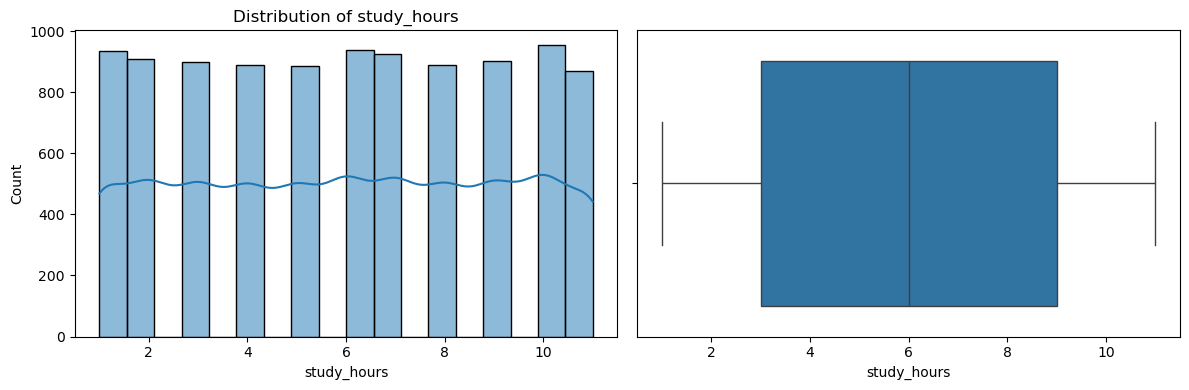

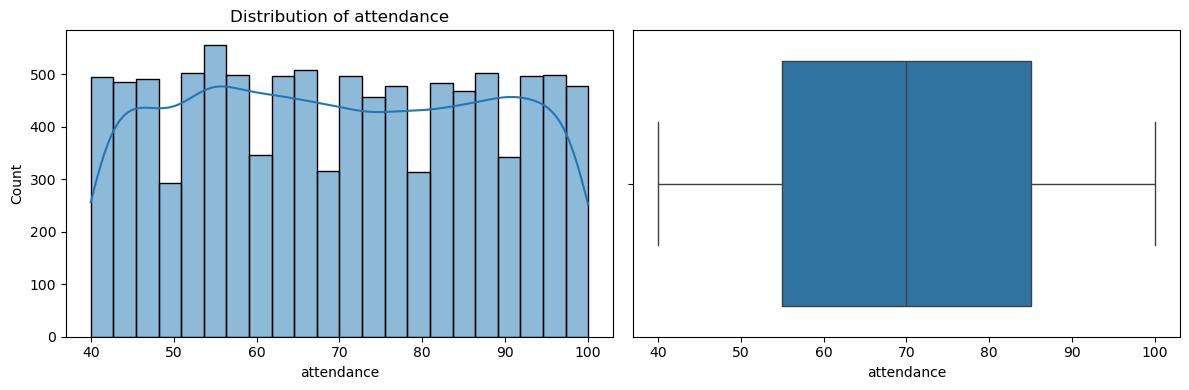

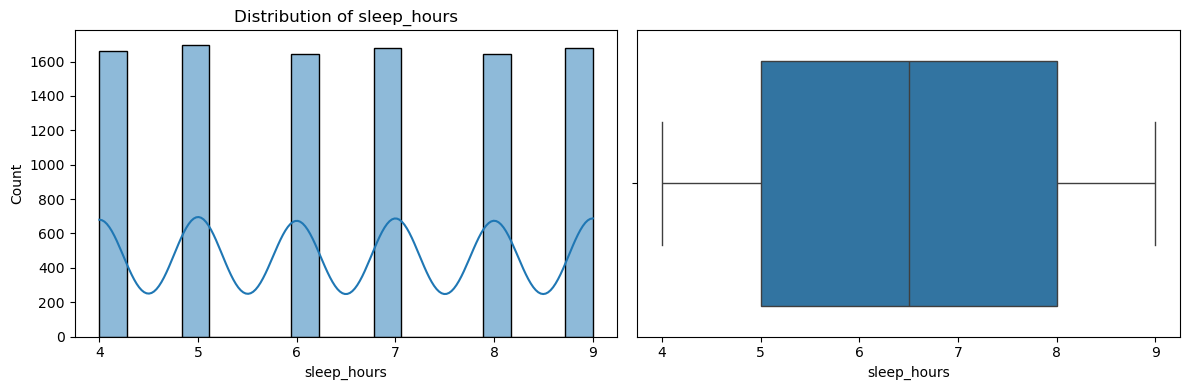

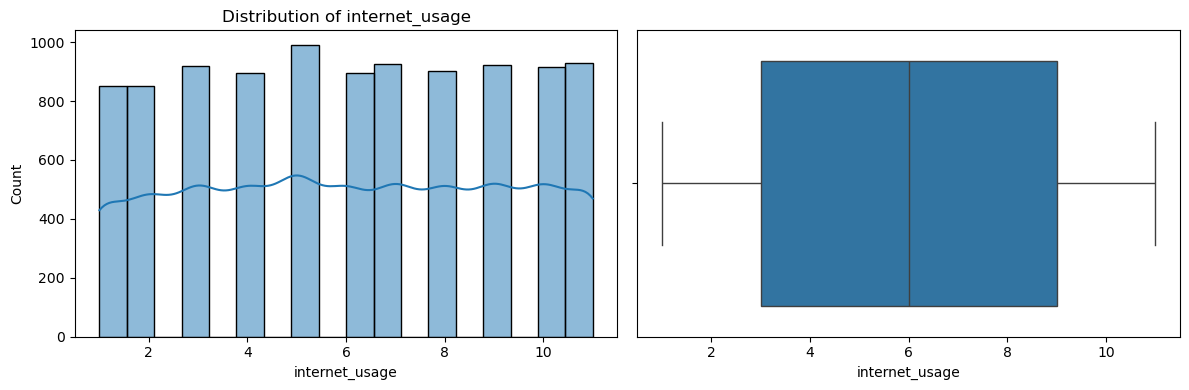

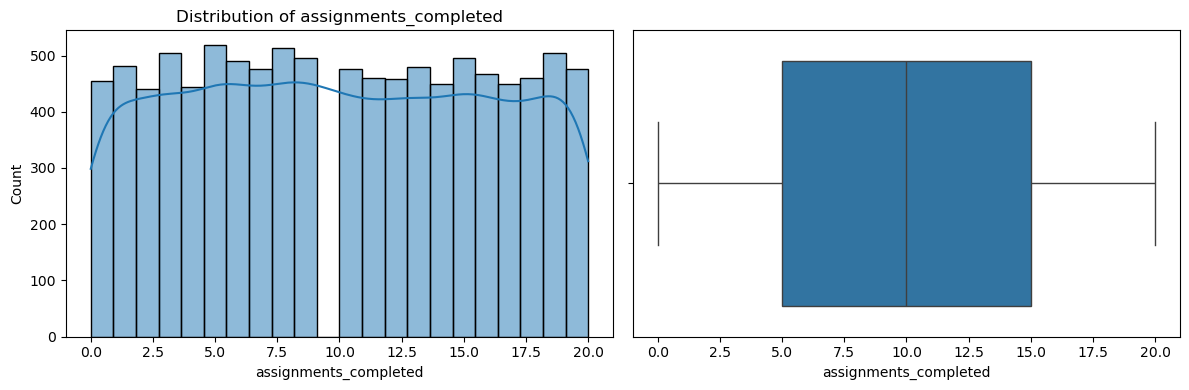

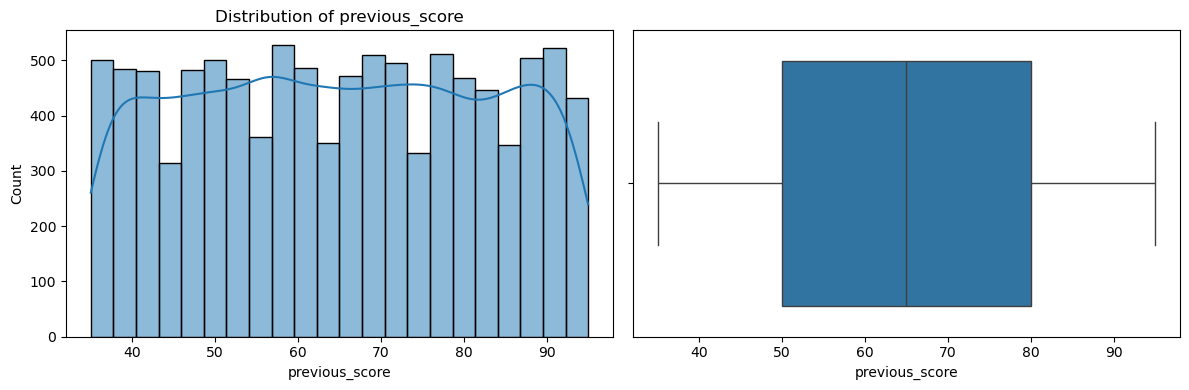

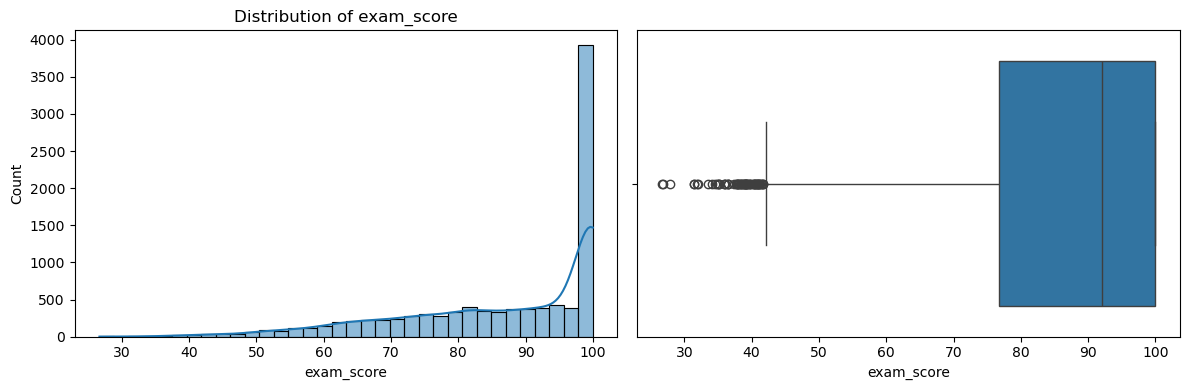

In [13]:
##For Numerical Columns:
for col in numerical_cols:
    fig,axes = plt.subplots(1,2,figsize=(12,4))
    sns.histplot(students_1[col], kde=True,ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    sns.boxplot(x=students_1[col],ax=axes[1])
    plt.tight_layout()
    plt.show()

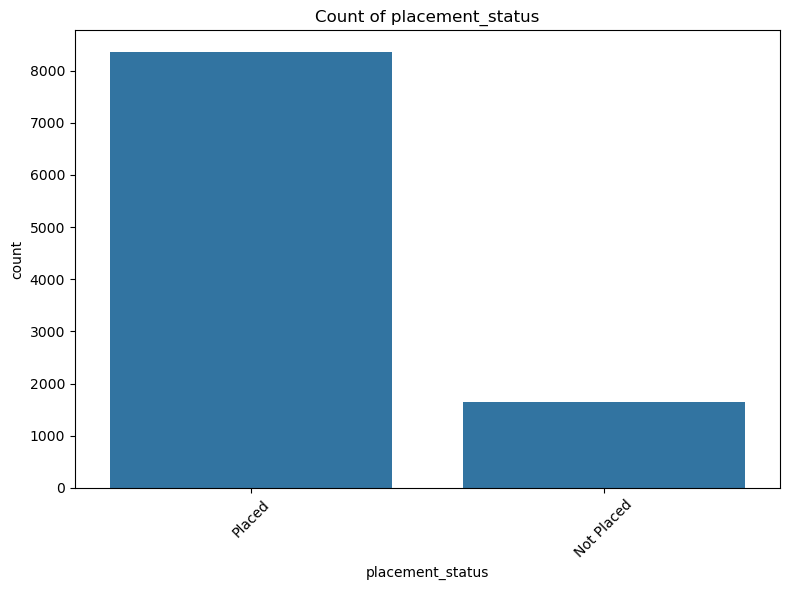

In [14]:
## For Categorical Cols:
for col in categorical_cols:
    plt.figure(figsize=(8,6))
    sns.countplot(data=students_1,x=col,order=students_1[col].value_counts().index)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**MODEL BUILDING**
- In this phase, we shall build a Logistic Model to Classify Students Placement Based on Academic and Behavioral Factors.
- The Target Variable (Variable to be Predicted == [Placement Status])
- The Predictor Variables include == [study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score', 'exam_score]

**SETTING UP THE ENVIRONMENT FOR MODEL BUILDING**
- We import all the Necessary Libraries to be used to build the model

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [16]:
## The variables:
students_1.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')

In [17]:
X = [['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score']]
y = ['placement_status']

In [18]:
students_1['placement_status'].unique()

array(['Placed', 'Not Placed'], dtype=object)

In [19]:
## Transform the Target Variable into numeric feature first:
placement_numeric = {
    'Not Placed' :0,
    'Placed':1
}
students_1['placement_numeric'] = students_1['placement_status'].map(placement_numeric)
students_1.head(2)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status,placement_numeric
0,7,56,8,7,10,62,100.0,Placed,1
1,4,69,5,3,8,56,100.0,Placed,1


## Lets define our variables for X and Y
- X are the Predictior variables
- y is The Target Variable --- The one we are trying to predict

In [20]:
X = students_1[['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score']]
y = students_1['placement_numeric']

In [21]:
## Obtain Split of the data in the ration 70% to 30%:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [22]:
## Check for the Split Set
print(f"Training set size:{len(X_train)}")
print(f"Test Set Size:{len(X_test)}")

Training set size:7000
Test Set Size:3000


**Logistic Regression Model Building**
- Use a Classifier ['CLF'] to fit and train the model.

In [23]:
clf = LogisticRegression().fit(X_train, y_train)

C:\Users\Gifton\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
## Obtain the Coefficients and The Intercepts:
## Coefficients:
clf.coef_

array([[ 0.10094559,  0.01904247,  0.03525077, -0.10450191,  0.06515276,
         0.02595242,  4.74281699]])

In [25]:
## For Intercept:
clf.intercept_

array([-335.1419274])

In [26]:
## Save the predictions  from the model:
y_pred = clf.predict(X_test)

In [27]:
clf.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], shape=(3000,))

In [28]:
## Obtain all the predicted probabilities by the Model:
clf.predict_proba(X_test)[::,-1]

array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
       1.00000000e+00, 1.00000000e+00, 1.65627014e-09], shape=(3000,))

## MODEL EVALUATION
- Having built the Model, it has to be evaluated to define if it is appropriate for modelling

**Confusion Matrix**
- A confusion matrix is a graphical representation  of how accurate the Model Classifier is at predictig the labels.

In [29]:
## Import the Confusion Matrix Module:
import sklearn.metrics as metrics

In [30]:
## Obttain the Matrix with Each Quadrant with values:
cm = metrics.confusion_matrix(y_test,y_pred, labels=clf.classes_)

In [31]:
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

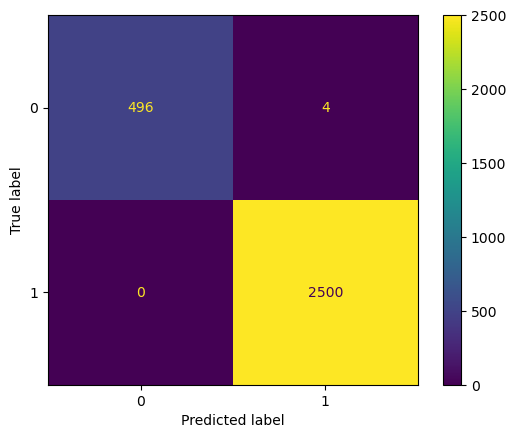

In [32]:
## Obtain the Visual Matrix:
disp.plot()

## Evaluate the Model
Accuracy (percentage of correct predictions):
accuracy = accuracy_score(y_test, y_pred) print(f"Accuracy: {accuracy * 100:.2f}%")

Confusion Matrix (shows where it got confused):

In [33]:
from sklearn.metrics import accuracy_score

In [34]:
##Evaluate the Model**
## Accuracy (percentage of correct predictions):
accuracy = accuracy_score(y_test, y_pred) 
print(f"Accuracy: {accuracy * 100:.2f}%")

## Confusion Matrix (shows where it got confused):

Accuracy: 99.87%


**Interpretation**
- Our Model achieves an Accuracy score of 99.87%